# Customer Retention & Churn Analysis

## Objective
Analyze customer data to identify churn patterns, understand retention drivers, and provide actionable recommendations to reduce customer churn and improve customer lifetime value.


## Import Libraries and Load Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Overview

In [23]:
df.info()
df.describe()
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Data Cleaning

In [27]:

# Fix TotalCharges datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values
df.isnull().sum()

# Drop missing values
df.dropna(inplace=True)

## Churn Rate

In [28]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
churn_rate = churn_rate.round(2)

print("Churn Rate (%):")
print(churn_rate)

Churn Rate (%):
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


## Churn rate by contract

In [4]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


## Churn Distribution

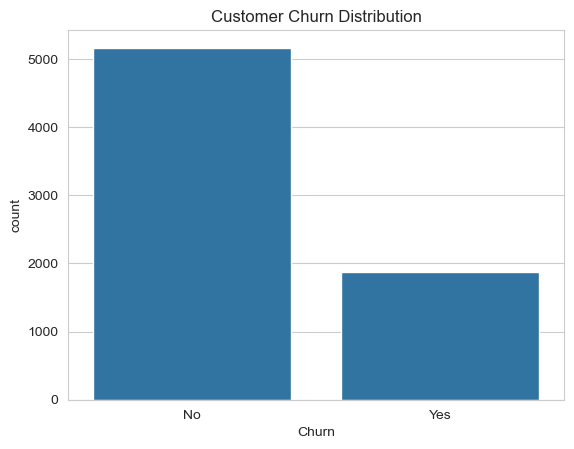

In [29]:
sns.countplot(data=df, x='Churn')
plt.title("Customer Churn Distribution")
plt.show()

Insight: Approximately 26% of customers have churned.

## Contract Type vs Churn

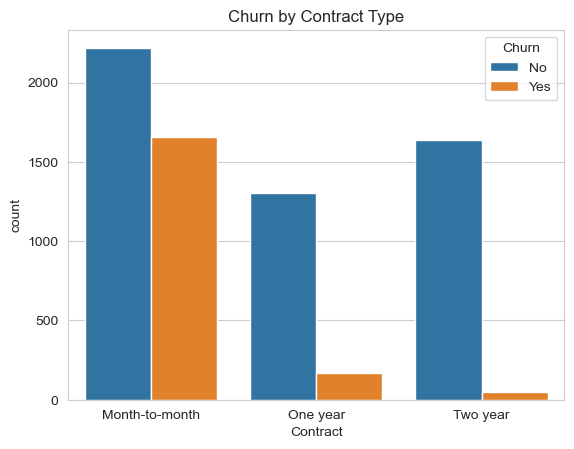

In [30]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn by Contract Type")
plt.show()

Insight:
Customers on month-to-month contracts show significantly higher churn compared to those on one-year or two-year contracts.
This suggests that lack of long-term commitment increases the likelihood of customer churn.

Recommendation:
Encourage long-term contracts through discounts or loyalty incentives.

## Tenure vs Churn (CUSTOMER LIFETIME)

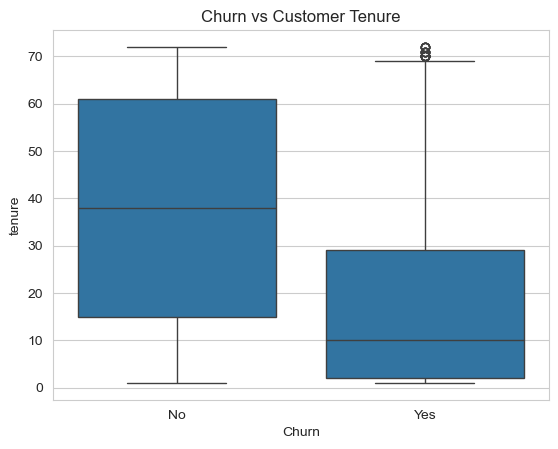

In [32]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title("Churn vs Customer Tenure")
plt.show()

Insight: Customers with shorter tenure are more likely to churn. This indicates that new customers are at the highest risk of leaving early.

Recommendation: Improve onboarding and early engagement strategies.

## Monthly Charges vs Churn

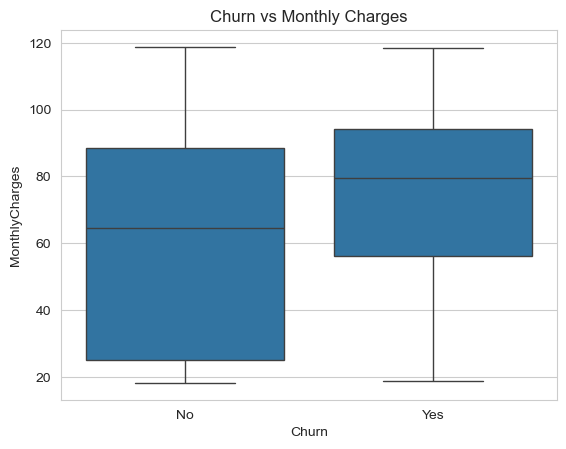

In [33]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Churn vs Monthly Charges")
plt.show()

Insight: Customers with higher monthly charges tend to churn more frequently. This suggests pricing sensitivity and potential dissatisfaction with value.

Recommendation: Review pricing strategy and offer better value packages.

## Internet Service vs Churn

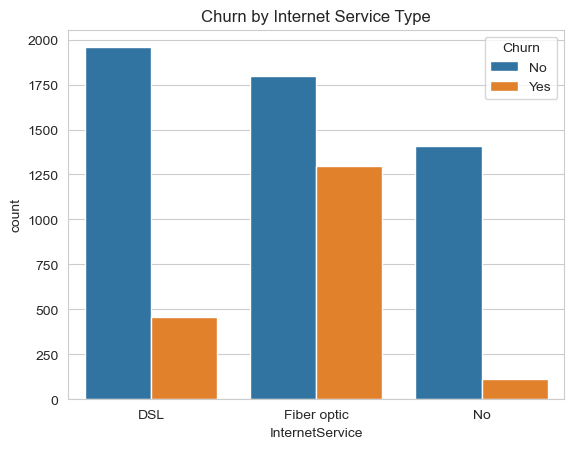

In [34]:
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title("Churn by Internet Service Type")
plt.show()

Insight: Customers using fiber optic services show higher churn rates.This may indicate higher expectations or dissatisfaction with service quality.

## Payment Method vs Churn

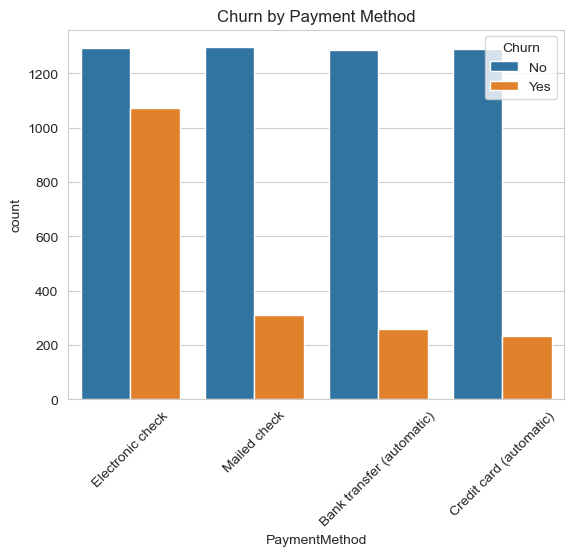

In [35]:
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

Insight: Customers using electronic check have higher churn rates.This may indicate lower commitment or higher friction in payment experience.

## Customer Churn Risk: Monthly Charges vs Tenure

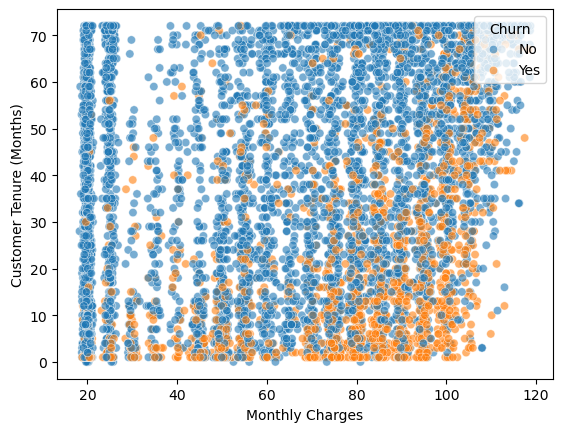

In [7]:
sns.scatterplot(data=df, x='MonthlyCharges', y='tenure', hue='Churn', alpha=0.6)
plt.xlabel("Monthly Charges")
plt.ylabel("Customer Tenure (Months)")
plt.legend(title="Churn", loc='upper right')
plt.show()

### Insight

Customers with **high monthly charges and low tenure** are more likely to churn.This indicates that new customers who are paying more are at a higher risk of leaving early, possibly due to unmet expectations or perceived lack of value.
 

## Key Insights

- High churn rate (~26%) indicates retention challenges
- Month-to-month contracts have the highest churn
- New customers (low tenure) are more likely to leave
- Higher monthly charges increase churn likelihood
- Fiber optic users show higher churn behavior
- Electronic check users churn more frequently

## Priority Actions

1. Reduce churn in month-to-month customers (highest impact)
2. Improve onboarding for new customers (early churn risk)
3. Review pricing for high-charge customers

## Business Recommendations
- Promote long-term contracts with incentives
- Improve onboarding experience for new customers
- Review pricing strategies to reduce churn risk
- Enhance service quality for high-churn segments
- Optimize payment systems to improve customer experience